In [1]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.shape

(8807, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [6]:
df['country'].value_counts().head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [7]:
df['release_year'].value_counts().head(10)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

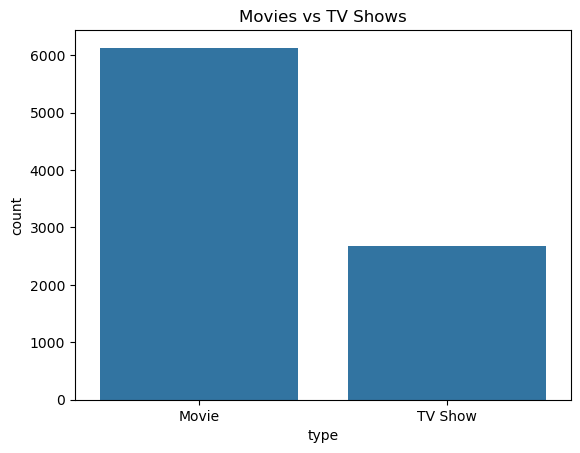

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

In [9]:
df['date_added'] = df['date_added'].str.strip()

In [10]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [11]:
df['date_added'] = pd.to_datetime(df['date_added'])

In [12]:
df['year_added'] = df['date_added'].dt.year

In [13]:
df.fillna({
    'director': "Unknown",
    'country': "Unknown",
    'cast': "Unknown"
}, inplace=True)

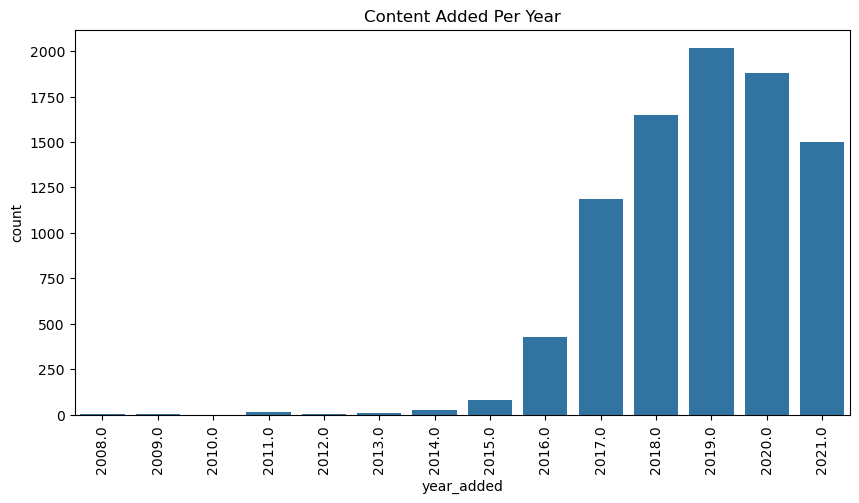

In [14]:
df['year_added'] = df['date_added'].dt.year

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.countplot(x='year_added', data=df)
plt.xticks(rotation=90)
plt.title("Content Added Per Year")
plt.show()

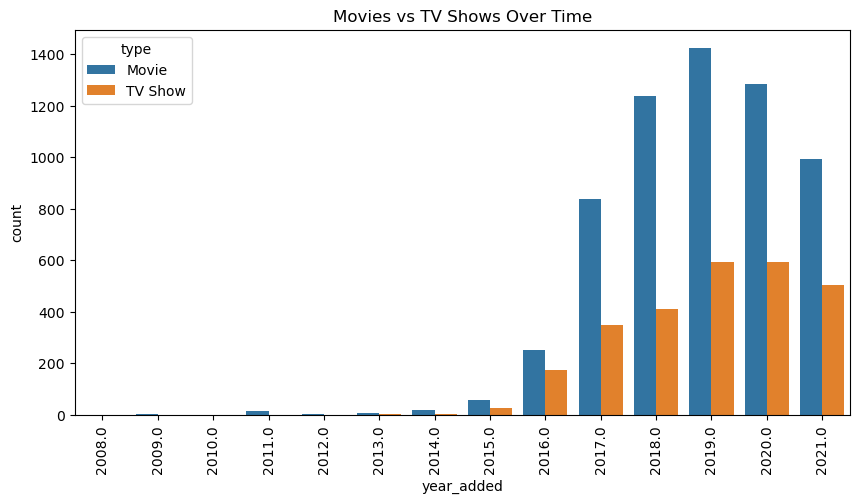

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(x='year_added', hue='type', data=df)
plt.xticks(rotation=90)
plt.title("Movies vs TV Shows Over Time")
plt.show()

In [16]:
df['rating'].value_counts().head(10)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

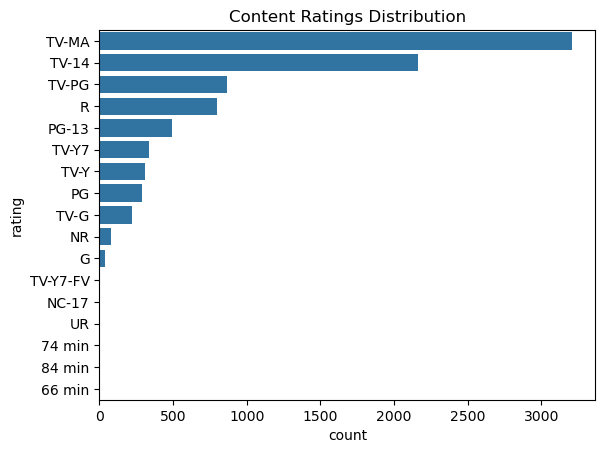

In [17]:
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title("Content Ratings Distribution")
plt.show()

In [18]:
from collections import Counter

genres = df['listed_in'].str.split(', ').sum()
top_genres = Counter(genres).most_common(10)

top_genres

[('International Movies', 2752),
 ('Dramas', 2427),
 ('Comedies', 1674),
 ('International TV Shows', 1351),
 ('Documentaries', 869),
 ('Action & Adventure', 859),
 ('TV Dramas', 763),
 ('Independent Movies', 756),
 ('Children & Family Movies', 641),
 ('Romantic Movies', 616)]

In [19]:
df_country = df[df['country'] != "Unknown"]

In [20]:
df_country['country'].value_counts().head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

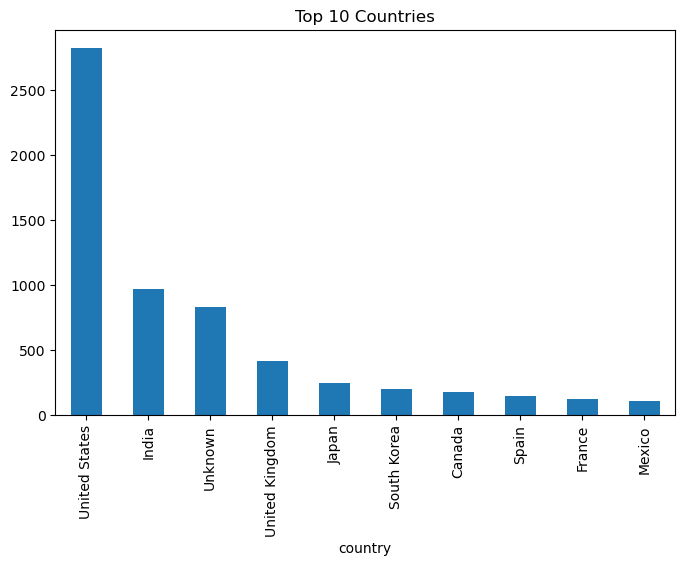

In [21]:
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(8,5))
top_countries.plot(kind='bar')
plt.title("Top 10 Countries")
plt.show()

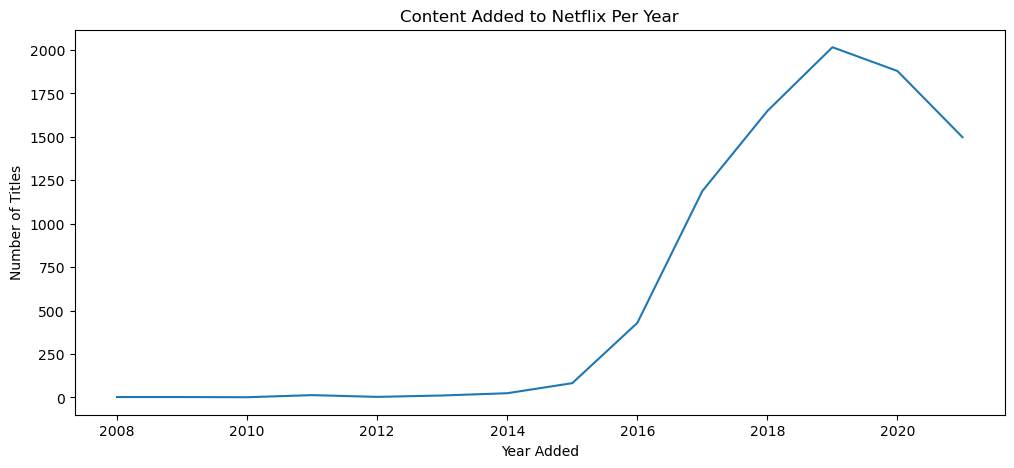

In [22]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

year_added_count = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,5))
sns.lineplot(x=year_added_count.index, y=year_added_count.values)
plt.title("Content Added to Netflix Per Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()

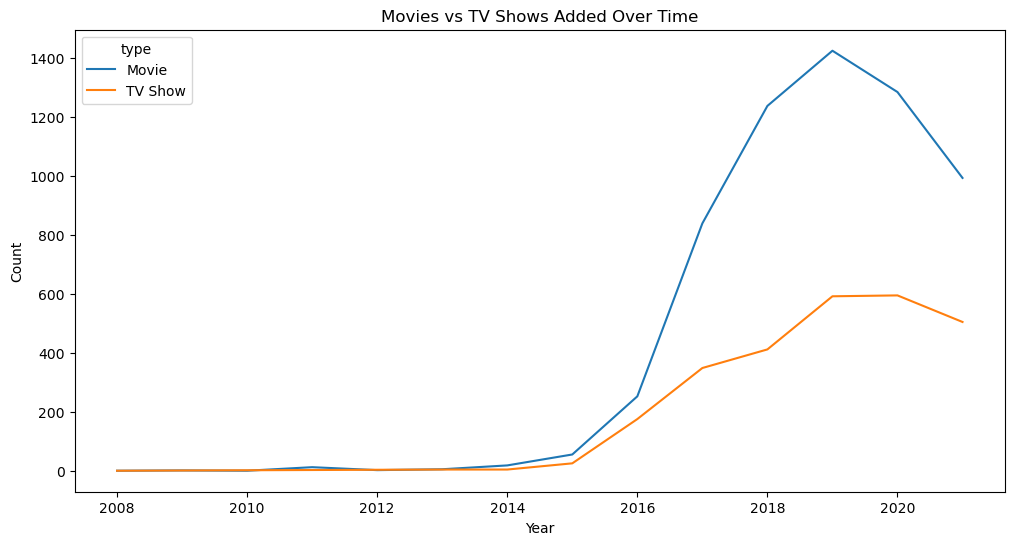

In [23]:
type_year = df.groupby(['year_added','type']).size().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.lineplot(data=type_year, x='year_added', y='count', hue='type')
plt.title("Movies vs TV Shows Added Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

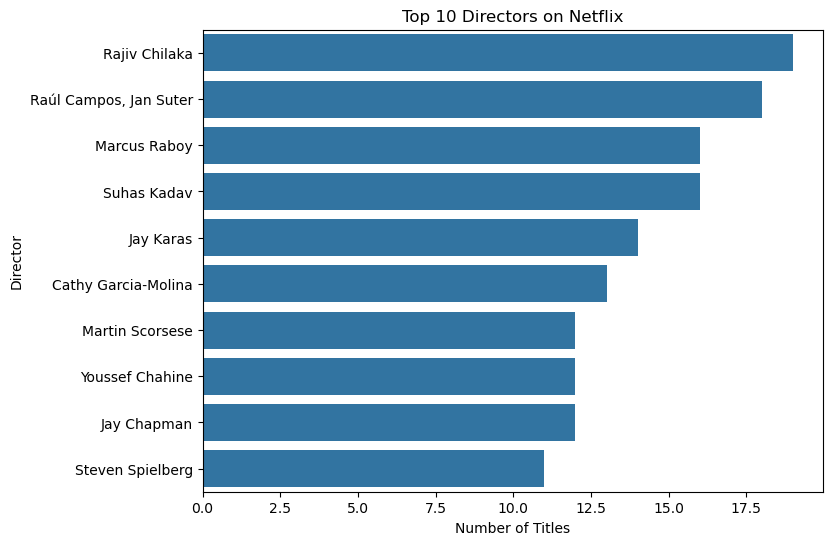

In [24]:
df['director'] = df['director'].fillna('Unknown')
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_directors.values, y=top_directors.index)
plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.show()

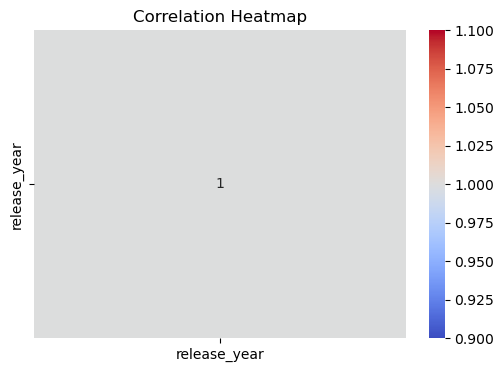

In [25]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['release_year']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

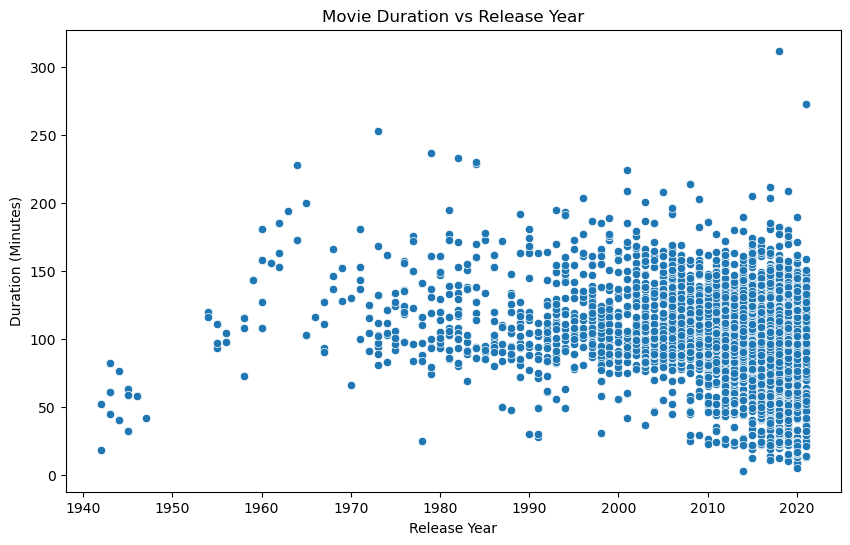

In [26]:
df_movies = df[df['type'] == 'Movie'].copy()
df_movies['duration'] = df_movies['duration'].str.replace(' min','')
df_movies['duration'] = pd.to_numeric(df_movies['duration'], errors='coerce')

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_movies, x='release_year', y='duration')
plt.title("Movie Duration vs Release Year")
plt.xlabel("Release Year")
plt.ylabel("Duration (Minutes)")
plt.show()

In [27]:
df['listed_in_split'] = df['listed_in'].str.split(', ')
genre_list = df.explode('listed_in_split')

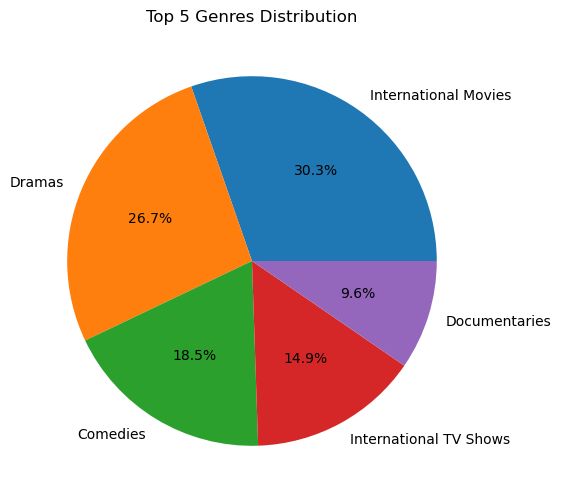

In [28]:
top_genres = genre_list['listed_in_split'].value_counts().head(5)

plt.figure(figsize=(6,6))
plt.pie(top_genres.values, labels=top_genres.index, autopct='%1.1f%%')
plt.title("Top 5 Genres Distribution")
plt.show()

In [29]:
pip install pycountry

Note: you may need to restart the kernel to use updated packages.


In [30]:
import plotly.express as px
import pycountry

# Remove Unknown
df_map = df[df['country'] != 'Unknown']

country_count = df_map['country'].value_counts().reset_index()
country_count.columns = ['country', 'count']

# Convert country names to ISO-3
def get_iso3(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except:
        return None

country_count['iso_alpha'] = country_count['country'].apply(get_iso3)

# Drop rows where conversion failed
country_count = country_count.dropna(subset=['iso_alpha'])

fig = px.choropleth(
    country_count,
    locations='iso_alpha',
    color='count',
    hover_name='country',
    color_continuous_scale='Reds',
    title='Netflix Content by Country'
)

fig.show()

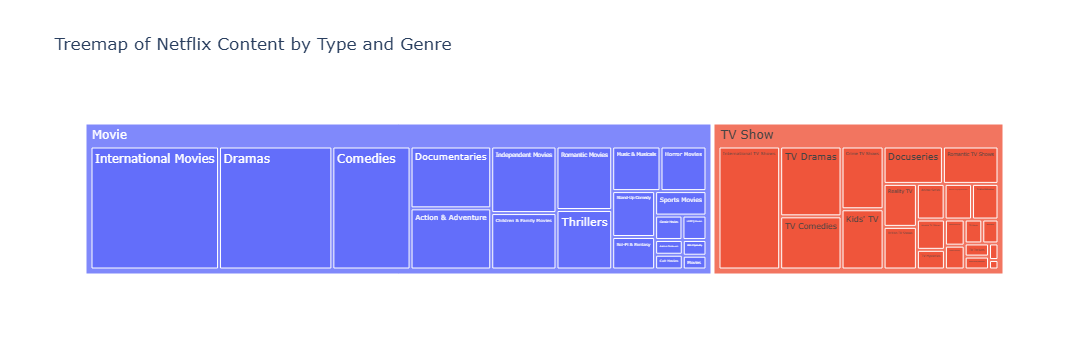

In [31]:
import plotly.express as px

df['listed_in_split'] = df['listed_in'].str.split(', ')
genre_df = df.explode('listed_in_split')

genre_type = genre_df.groupby(['type','listed_in_split']).size().reset_index(name='count')

fig = px.treemap(
    genre_type,
    path=['type','listed_in_split'],
    values='count',
    title='Treemap of Netflix Content by Type and Genre'
)

fig.show()

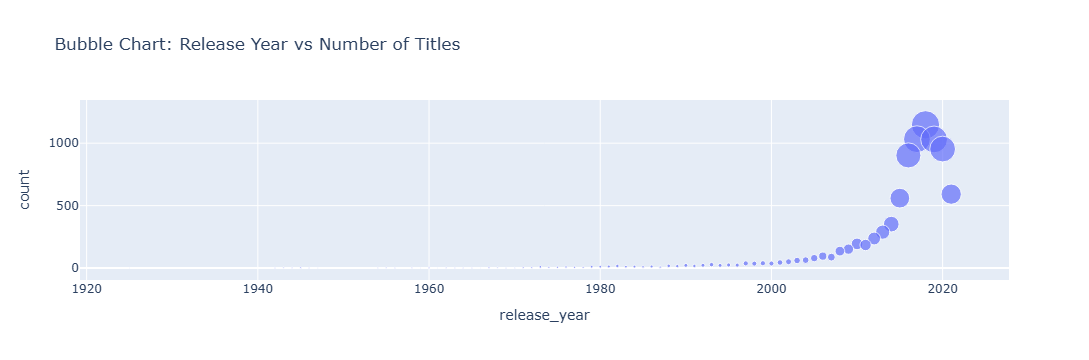

In [32]:
year_count = df['release_year'].value_counts().reset_index()
year_count.columns = ['release_year', 'count']

fig = px.scatter(
    year_count,
    x='release_year',
    y='count',
    size='count',
    title='Bubble Chart: Release Year vs Number of Titles',
)

fig.show()